#**Predicting climate linked vector borne disease outbreaks**

---




# #**EDA**

#**First Dataset**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('/content/Outbreaks.csv')

In [3]:
df.head()

,Unnamed: 0,Country,iso2,iso3,Year,icd10n,icd103n,icd104n,icd10c,icd103c,icd104c,icd11c1,icd11c2,icd11c3,icd11l1,icd11l2,icd11l3,Disease,DONs,Definition
0,1,Afghanistan,AF,AFG,2000,Arthropod-borne viral fevers and viral haemorr...,Unspecified viral haemorrhagic fever,Unspecified viral haemorrhagic fever,A92-A99,A99,A990,1,D86,1D86,Certain infectious or parasitic diseases,Certain other viral diseases,"Viral haemorrhagic fever, not elsewhere classi...",Unspecified viral haemorrhagic fever,"DON0404, DON0399",NaN
1,2,Afghanistan,AF,AFG,2002,Intestinal infectious diseases,Other gastroenteritis and colitis of infectiou...,Other and unspecified gastroenteritis and coli...,A00-A09,A09,A090,1,A40,1A40,Certain infectious or parasitic diseases,Gastroenteritis or colitis of infectious origin,Gastroenteritis or colitis without specificati...,Infectious gastroenteritis or colitis without ...,DON0607,NaN
2,3,Afghanistan,AF,AFG,1998,Intestinal infectious diseases,Cholera,Classical cholera,A00-A09,A00,A000,1,A00,1A00,Certain infectious or parasitic diseases,Gastroenteritis or colitis of infectious origin,Bacterial intestinal infections,Cholera,"DON0253, DON0249, DON0248",Intestinal infection due to Vibrio cholerae
3,4,Afghanistan,AF,AFG,1999,Codes for special purposes,Provisional assignment of new diseases of unce...,Severe acute respiratory syndrome [SARS],U00-U49,U04,U049,1,D65,1D65,Certain infectious or parasitic diseases,Certain zoonotic viral diseases,Severe acute respiratory syndrome,Severe acute respiratory syndrome,DON0294,"A disease of the respiratory system, caused by..."
4,5,Afghanistan,AF,AFG,2000,Intestinal infectious diseases,Cholera,Classical cholera,A00-A09,A00,A000,1,A00,1A00,Certain infectious or parasitic diseases,Gastroenteritis or colitis of infectious origin,Bacterial intestinal infections,Cholera,DON0413,Intestinal infection due to Vibrio cholerae


In [4]:
df.shape

(2227, 20)

In [5]:
df.isnull().sum()

,0
Unnamed: 0,0
Country,0
iso2,4
iso3,0
Year,0
icd10n,0
icd103n,0
icd104n,0
icd10c,0
icd103c,0


In [6]:
null_iso2 = df[df['iso2'].isnull()]
null_iso2

,Unnamed: 0,Country,iso2,iso3,Year,icd10n,icd103n,icd104n,icd10c,icd103c,icd104c,icd11c1,icd11c2,icd11c3,icd11l1,icd11l2,icd11l3,Disease,DONs,Definition
953,954,Namibia,NaN,NAM,2018,Viral hepatitis,Other acute viral hepatitis,Acute hepatitis E,B15-B19,B17,B172,1,E50,1.00E+50,Certain infectious or parasitic diseases,Viral hepatitis,Acute viral hepatitis,Acute hepatitis E,DON2391,"A disease of the liver, caused by an acute inf..."
954,955,Namibia,NaN,NAM,2009,Influenza and pneumonia,Influenza due to identified zoonotic or pandem...,Influenza due to identified zoonotic or pandem...,J09-J18,J09,J090,1,E31,1.00E+31,Certain infectious or parasitic diseases,Influenza,Influenza,Influenza due to identified zoonotic or pande...,DON1437,"Influenza, caused by influenza virus strains o..."
955,956,Namibia,NaN,NAM,2006,Viral infections of the central nervous system,Acute poliomyelitis,"Acute poliomyelitis, unspecified",A80-A89,A80,A809,1,C81,1C81,Certain infectious or parasitic diseases,Viral infections of the central nervous system,Acute poliomyelitis,"Acute poliomyelitis, unspecified",DON1128,"A disease of the nervous system, caused by hum..."
956,957,Namibia,NaN,NAM,1999,Certain zoonotic bacterial diseases,Plague,"Plague, unspecified",A20-A28,A20,A209,1,B93,1B93,Certain infectious or parasitic diseases,Certain zoonotic bacterial diseases,Plague,"Plague, unspecified",DON0325,A disease caused by an infection with the gram...


In [7]:
values_to_fill={'iso2':'NM'}
df.fillna(value=values_to_fill,inplace=True)

In [8]:
df[df['Country'] == 'Namibia']

,Unnamed: 0,Country,iso2,iso3,Year,icd10n,icd103n,icd104n,icd10c,icd103c,icd104c,icd11c1,icd11c2,icd11c3,icd11l1,icd11l2,icd11l3,Disease,DONs,Definition
953,954,Namibia,NM,NAM,2018,Viral hepatitis,Other acute viral hepatitis,Acute hepatitis E,B15-B19,B17,B172,1,E50,1.00E+50,Certain infectious or parasitic diseases,Viral hepatitis,Acute viral hepatitis,Acute hepatitis E,DON2391,"A disease of the liver, caused by an acute inf..."
954,955,Namibia,NM,NAM,2009,Influenza and pneumonia,Influenza due to identified zoonotic or pandem...,Influenza due to identified zoonotic or pandem...,J09-J18,J09,J090,1,E31,1.00E+31,Certain infectious or parasitic diseases,Influenza,Influenza,Influenza due to identified zoonotic or pande...,DON1437,"Influenza, caused by influenza virus strains o..."
955,956,Namibia,NM,NAM,2006,Viral infections of the central nervous system,Acute poliomyelitis,"Acute poliomyelitis, unspecified",A80-A89,A80,A809,1,C81,1C81,Certain infectious or parasitic diseases,Viral infections of the central nervous system,Acute poliomyelitis,"Acute poliomyelitis, unspecified",DON1128,"A disease of the nervous system, caused by hum..."
956,957,Namibia,NM,NAM,1999,Certain zoonotic bacterial diseases,Plague,"Plague, unspecified",A20-A28,A20,A209,1,B93,1B93,Certain infectious or parasitic diseases,Certain zoonotic bacterial diseases,Plague,"Plague, unspecified",DON0325,A disease caused by an infection with the gram...


In [9]:
null_icd11l2 = df[df['icd11l2'].isnull()]
null_icd11l2

,Unnamed: 0,Country,iso2,iso3,Year,icd10n,icd103n,icd104n,icd10c,icd103c,icd104c,icd11c1,icd11c2,icd11c3,icd11l1,icd11l2,icd11l3,Disease,DONs,Definition
8,9,Afghanistan,AF,AFG,1999,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON0291,NaN
29,30,Angola,AO,AGO,2007,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified","DON1258, DON1257",NaN
43,44,Angola,AO,AGO,2011,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON1598,NaN
200,201,Cambodia,KH,KHM,2012,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified","DON1648, DON1651, DON1650",NaN
401,402,Congo Democratic Republic of the,CD,COD,2007,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON1236,NaN
838,839,Liberia,LR,LBR,2017,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON2327,NaN
883,884,Malaysia,MY,MYS,1997,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified","DON0167, DON0161, DON0162, DON0166, DON0164",NaN
938,939,Mozambique,MZ,MOZ,1998,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON0277,NaN
1263,1264,South Africa,ZA,ZAF,2008,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON1329,NaN
1292,1293,Sri Lanka,LK,LKA,2005,Other infectious diseases,Other and unspecified infectious diseases,Other and unspecified infectious diseases,B99-B99,B99,B990,1,H0Z,1H0Z,Certain infectious or parasitic diseases,NaN,NaN,"Infection, unspecified",DON0946,NaN


In [10]:
df = df.fillna({'icd11l2': 'Unknown', 'icd11l3': 'Unknown'})

In [11]:
df['Definition'] = df['Definition'].fillna('Not specified')


In [12]:
df.isnull().sum()

,0
Unnamed: 0,0
Country,0
iso2,0
iso3,0
Year,0
icd10n,0
icd103n,0
icd104n,0
icd10c,0
icd103c,0


In [13]:
print(df.describe(include=['object']))

                                 Country  iso2  iso3  \
count                               2227  2227  2227   
unique                               233   233   233   
top     Congo Democratic Republic of the    CD   COD   
freq                                  57    57    57   

                                                   icd10n  \
count                                                2227   
unique                                                 20   
top     Provisional assignment of new diseases of unce...   
freq                                                  732   

                     icd103n                     icd104n   icd10c icd103c  \
count                   2227                        2227     2227    2227   
unique                    50                          70       19      49   
top     Emergency use of U07  COVID-19, virus identified  U00-U49     U07   
freq                     665                         665      764     665   

       icd104c icd11c1 icd1

In [14]:
country_counts = df['Country'].value_counts().head(10)
print(country_counts)

Country
Congo Democratic Republic of the    57
Nigeria                             44
United States of America            37
Sudan                               32
Chad                                31
China                               31
Brazil                              31
France                              28
Burkina Faso                        28
Niger                               28
Name: count, dtype: int64


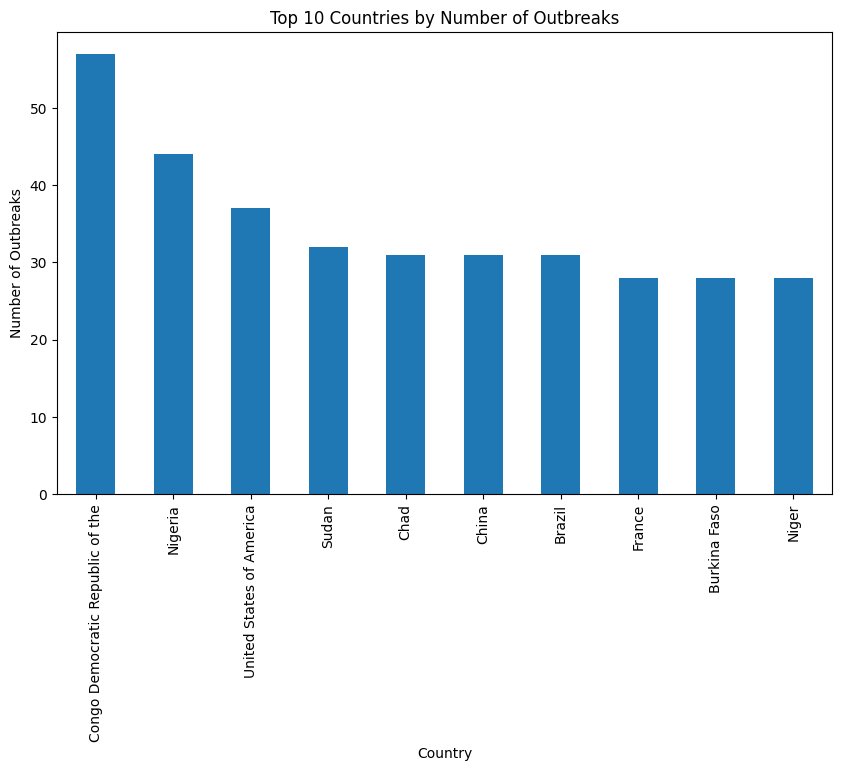

In [15]:
plt.figure(figsize=(10,6))
country_counts.plot(kind='bar')
plt.title("Top 10 Countries by Number of Outbreaks")
plt.xlabel("Country")
plt.ylabel("Number of Outbreaks")
plt.show()

In [16]:
disease_counts = df['Disease'].value_counts().head(10)
print(disease_counts)

Disease
COVID-19                                                             665
 Influenza due to identified zoonotic or pandemic influenza virus    409
Cholera                                                              167
Acute poliomyelitis, unspecified                                     112
Yellow fever, unspecified                                            104
Meningococcal meningitis                                              95
Measles                                                               83
Middle East respiratory syndrome                                      67
Dengue fever, unspecified                                             50
Unspecified viral haemorrhagic fever                                  49
Name: count, dtype: int64


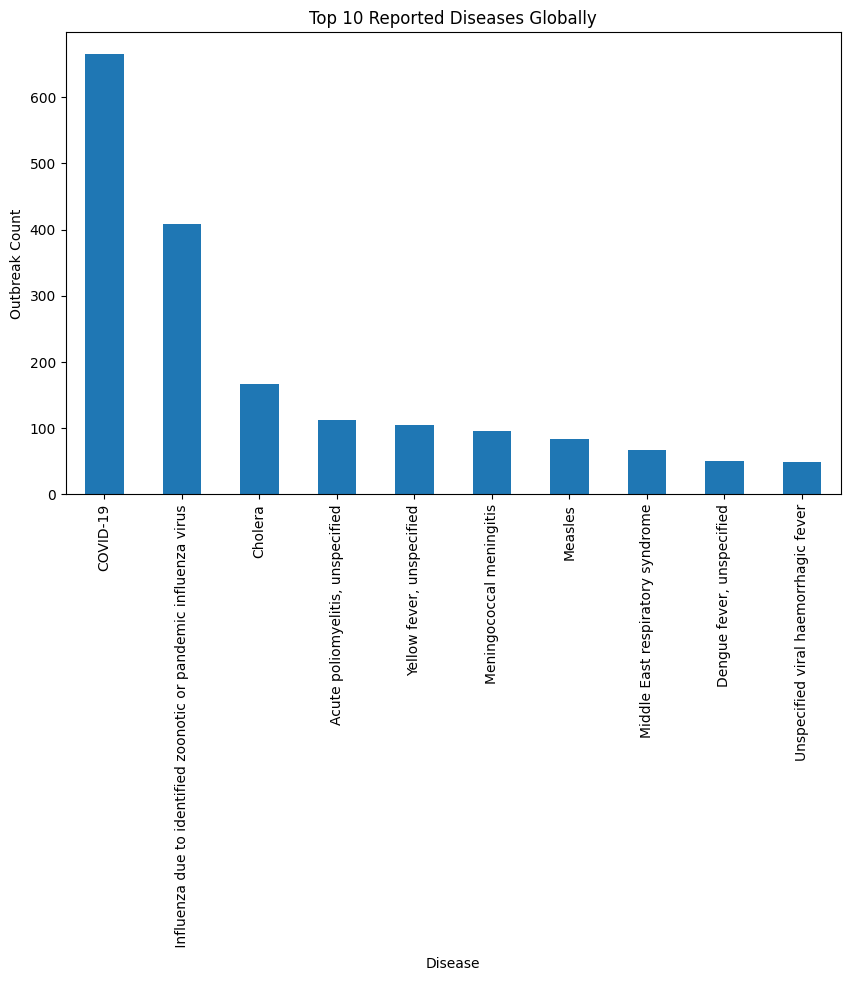

In [17]:
plt.figure(figsize=(10,6))
disease_counts.plot(kind='bar')
plt.title("Top 10 Reported Diseases Globally")
plt.xlabel("Disease")
plt.ylabel("Outbreak Count")
plt.show()


In [18]:
yearly_counts = df['Year'].value_counts().sort_index()
print(yearly_counts)

Year
1996     78
1997     42
1998     86
1999     67
2000     40
2001     49
2002     36
2003     83
2004     73
2005     40
2006     43
2007     29
2008     48
2009    207
2010     73
2011     48
2012     33
2013     33
2014     40
2015     57
2016     58
2017     57
2018     43
2019     95
2020    257
2021    275
2022    237
Name: count, dtype: int64


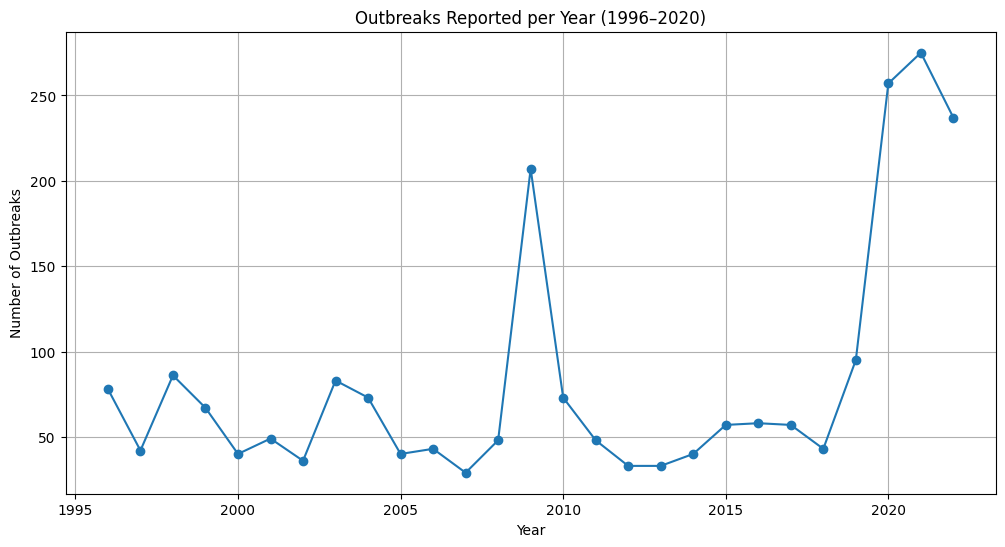

In [19]:
plt.figure(figsize=(12,6))
plt.plot(yearly_counts.index, yearly_counts.values, marker='o')
plt.title("Outbreaks Reported per Year (1996–2020)")
plt.xlabel("Year")
plt.ylabel("Number of Outbreaks")
plt.grid(True)
plt.show()

In [20]:
top_years_with_most_outbreaks = df['Year'].value_counts().sort_values(ascending=False).head(10)
print(top_years_with_most_outbreaks)

Year
2021    275
2020    257
2022    237
2009    207
2019     95
1998     86
2003     83
1996     78
2004     73
2010     73
Name: count, dtype: int64


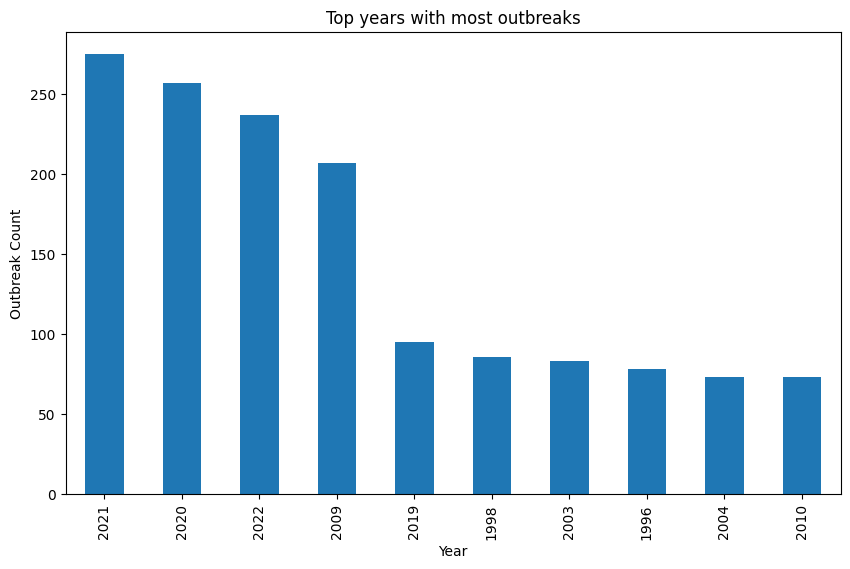

In [21]:
plt.figure(figsize=(10,6))
top_years_with_most_outbreaks.plot(kind='bar')
plt.title("Top years with most outbreaks")
plt.xlabel("Year")
plt.ylabel("Outbreak Count")
plt.show()

In [22]:
print(df['icd11l1'].value_counts().head(10))
print(df['icd11l2'].value_counts().head(10))
print(df['icd11l3'].value_counts().head(10))


icd11l1
Certain infectious or parasitic diseases      1545
Codes for special purposes                     665
Extension Codes                                 14
Diseases of the respiratory system               2
Diseases of the nervous system                   1
Name: count, dtype: int64
icd11l2
International provisional assignment of new diseases of uncertain aetiology and emergency use    665
Influenza                                                                                        409
Gastroenteritis or colitis of infectious origin                                                  198
Certain arthropod-borne viral fevers                                                             197
Certain zoonotic viral diseases                                                                  175
Viral infections of the central nervous system                                                   163
Other bacterial diseases                                                                         

In [23]:
df['Country'].value_counts()

,count
Country,
Congo Democratic Republic of the,57
Nigeria,44
United States of America,37
Sudan,32
Chad,31
...,...
Macao,1
Nauru,1
Tuvalu,1


In [24]:
df['Disease'].value_counts()

,count
Disease,
COVID-19,665
Influenza due to identified zoonotic or pandemic influenza virus,409
Cholera,167
"Acute poliomyelitis, unspecified",112
"Yellow fever, unspecified",104
...,...
"Coccidioidomycosis, unspecified",1
Tuberculosis of the respiratory system,1
Haemorrhagic fever with renal syndrome,1


#**Second dataset**

In [25]:
  c_df=pd.read_csv('/content/update_temperature.csv')
  c_df.head()

,Year,Country,Avg_Temperature_degC,CO2_Emissions_tons_per_capita,Sea_Level_Rise_mm,Rainfall_mm,Population,Renewable_Energy_pct,Extreme_Weather_Events,Forest_Area_pct
0,2000,United States,13.5,20.2,0,715,282500000,6.2,38,33.1
1,2000,China,12.8,2.7,0,645,1267000000,16.5,24,18.8
2,2000,Germany,9.3,10.1,0,700,82200000,6.6,12,31.8
3,2000,Brazil,24.9,1.9,0,1760,175000000,83.7,18,65.4
4,2000,Australia,21.7,17.2,0,534,19200000,8.8,11,16.2


In [26]:
c_df.describe()

,Year,Avg_Temperature_degC,CO2_Emissions_tons_per_capita,Sea_Level_Rise_mm,Rainfall_mm,Population,Renewable_Energy_pct,Extreme_Weather_Events,Forest_Area_pct
count,156.000000,156.000000,156.000000,156.000000,156.000000,1.560000e+02,156.000000,156.000000,156.000000
mean,2012.333333,17.620513,7.673718,24.333333,937.397436,2.952075e+08,31.203846,20.185897,32.191667
std,8.326664,7.221658,5.450198,16.916239,532.954803,4.414786e+08,26.741843,10.951980,18.335613
min,2000.000000,5.100000,0.500000,0.000000,54.000000,1.915300e+07,0.000000,2.000000,0.500000
25%,2005.000000,12.800000,2.175000,10.000000,576.000000,5.448750e+07,14.850000,12.750000,17.225000
50%,2012.500000,15.500000,7.350000,23.500000,775.500000,1.230873e+08,19.800000,18.000000,32.000000
75%,2020.000000,25.225000,10.800000,36.000000,1151.750000,2.132000e+08,43.050000,25.000000,48.125000
max,2024.000000,28.500000,20.200000,59.000000,2726.000000,1.426000e+09,87.200000,64.000000,68.500000


In [27]:
c_df.isnull().sum()

,0
Year,0
Country,0
Avg_Temperature_degC,0
CO2_Emissions_tons_per_capita,0
Sea_Level_Rise_mm,0
Rainfall_mm,0
Population,0
Renewable_Energy_pct,0
Extreme_Weather_Events,0
Forest_Area_pct,0


In [28]:
c_df['Country'].count()

np.int64(156)

In [29]:

c_df['Country'].value_counts()

,count
Country,
China,12
Germany,12
Brazil,12
Russia,12
Australia,12
India,12
Nigeria,12
United States,6
South Africa,6


In [30]:
c_df.shape

(156, 10)

In [31]:
country_counts = c_df['Country'].value_counts().head(10)
print(country_counts)

Country
China            12
Germany          12
Brazil           12
Russia           12
Australia        12
India            12
Nigeria          12
United States     6
South Africa      6
Canada            6
Name: count, dtype: int64


In [32]:
c_df.columns

Index(['Year', 'Country', 'Avg_Temperature_degC',
       'CO2_Emissions_tons_per_capita', 'Sea_Level_Rise_mm', 'Rainfall_mm',
       'Population', 'Renewable_Energy_pct', 'Extreme_Weather_Events',
       'Forest_Area_pct'],
      dtype='object')

In [33]:
avg_temp_trend=c_df.groupby('Year')['Avg_Temperature_degC'].mean()
avg_temp_trend

,Avg_Temperature_degC
Year,
2000,17.000000
2005,17.211538
2010,17.411538
2015,17.746154
2020,18.053846
2024,18.300000


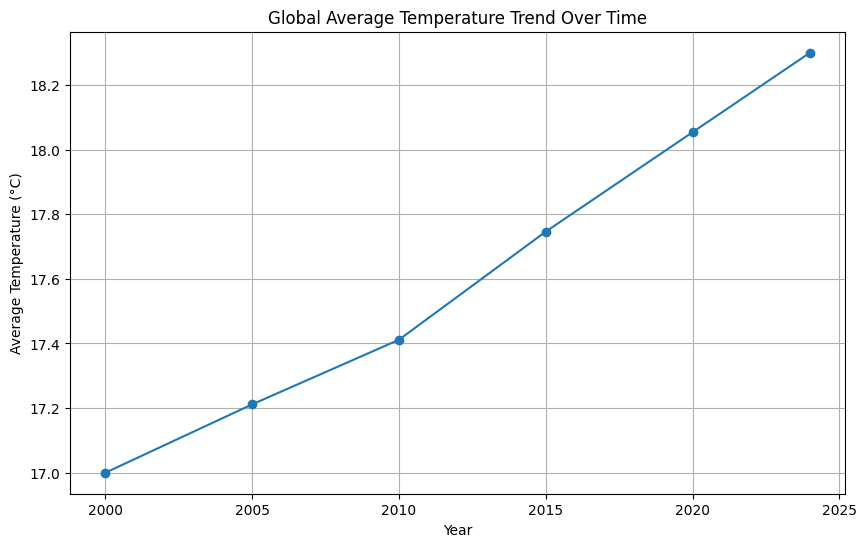

In [34]:
plt.figure(figsize=(10,6))
avg_temp_trend.plot(marker='o')
plt.title("Global Average Temperature Trend Over Time")
plt.xlabel("Year")
plt.ylabel("Average Temperature (°C)")
plt.grid(True)
plt.show()

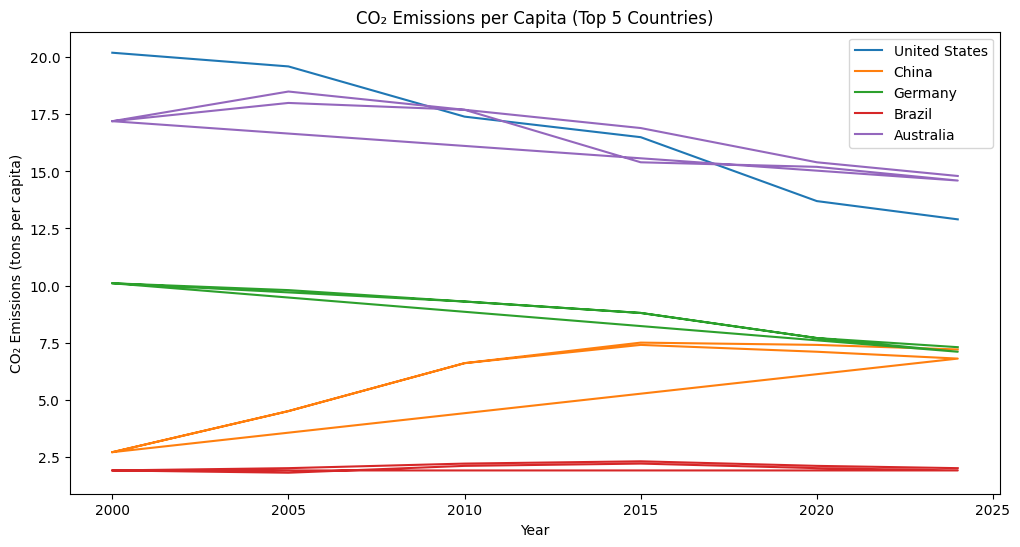

In [35]:
plt.figure(figsize=(12,6))
for country in c_df['Country'].unique()[:5]:
    subset = c_df[c_df['Country'] == country]
    plt.plot(subset['Year'], subset['CO2_Emissions_tons_per_capita'], label=country)
plt.title("CO₂ Emissions per Capita (Top 5 Countries)")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (tons per capita)")
plt.legend()
plt.show()

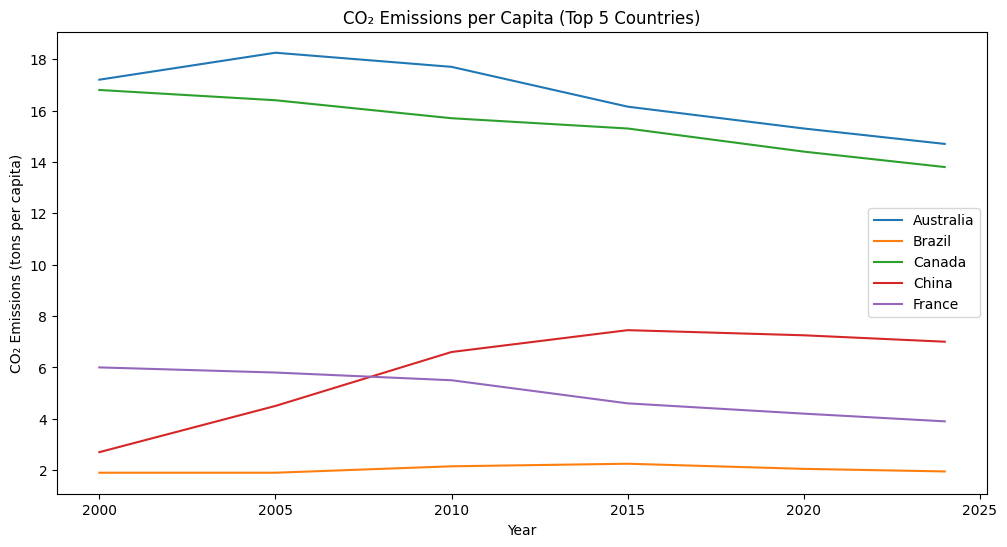

In [36]:
# Aggregate data in case there are duplicates per (Country, Year)
grouped = (
    c_df.groupby(['Country', 'Year'])['CO2_Emissions_tons_per_capita']
        .mean()
        .reset_index()
)

plt.figure(figsize=(12,6))

for country in grouped['Country'].unique()[:5]:
    subset = grouped[grouped['Country'] == country].sort_values('Year')
    plt.plot(subset['Year'], subset['CO2_Emissions_tons_per_capita'], label=country)

plt.title("CO₂ Emissions per Capita (Top 5 Countries)")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions (tons per capita)")
plt.legend()
plt.show()


In [37]:
sea_level_trend=c_df.groupby('Year')['Sea_Level_Rise_mm'].mean()
sea_level_trend

,Sea_Level_Rise_mm
Year,
2000,0.000000
2005,10.076923
2010,19.846154
2015,29.384615
2020,39.576923
2024,47.115385


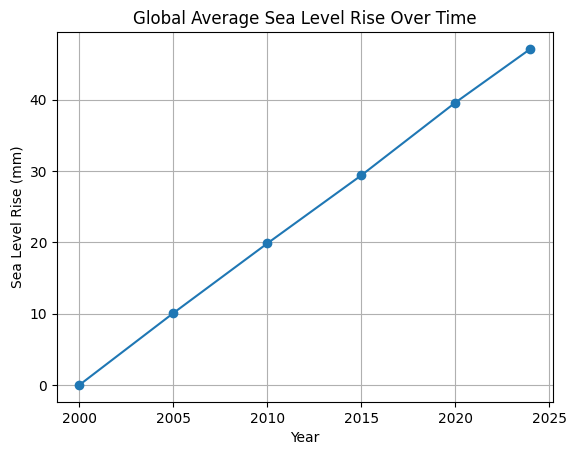

In [38]:
sea_level_trend.plot(kind='line', marker='o')
plt.title("Global Average Sea Level Rise Over Time")
plt.xlabel("Year")
plt.ylabel("Sea Level Rise (mm)")
plt.grid(True)
plt.show()

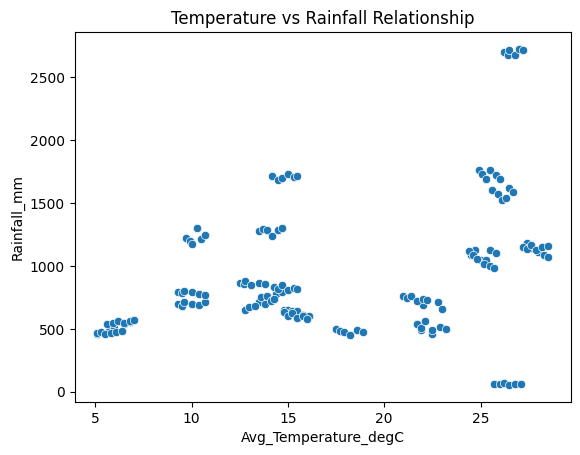

In [39]:
sns.scatterplot(x='Avg_Temperature_degC', y='Rainfall_mm', data=c_df)
plt.title("Temperature vs Rainfall Relationship")
plt.show()

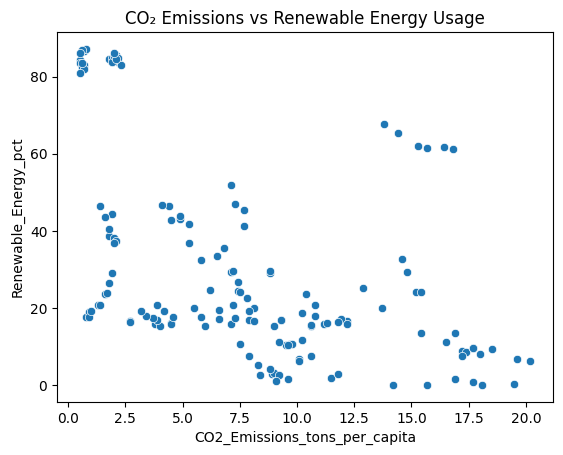

In [40]:
sns.scatterplot(x='CO2_Emissions_tons_per_capita', y='Renewable_Energy_pct', data=c_df)
plt.title("CO₂ Emissions vs Renewable Energy Usage")
plt.show()

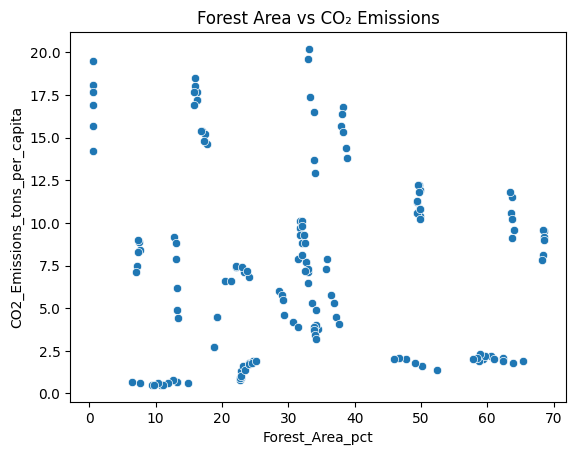

In [41]:
sns.scatterplot(x='Forest_Area_pct', y='CO2_Emissions_tons_per_capita', data=c_df)
plt.title("Forest Area vs CO₂ Emissions")
plt.show()

In [42]:
hottest_countries=c_df.groupby('Country')['Avg_Temperature_degC'].mean().sort_values(ascending=False).head(10)
hottest_countries

,Avg_Temperature_degC
Country,
Nigeria,27.816667
Indonesia,26.683333
Saudi Arabia,26.383333
Brazil,25.808333
India,25.083333
Australia,22.350000
Mexico,21.583333
South Africa,18.133333
Spain,15.383333


In [43]:
rain_countries=c_df.groupby('Country')['Rainfall_mm'].mean().sort_values(ascending=False).head(10)
rain_countries

,Rainfall_mm
Country,
Indonesia,2701.833333
Japan,1707.166667
Brazil,1649.166667
South Korea,1279.000000
United Kingdom,1225.333333
Nigeria,1134.666667
India,1066.416667
France,860.000000
Italy,822.000000


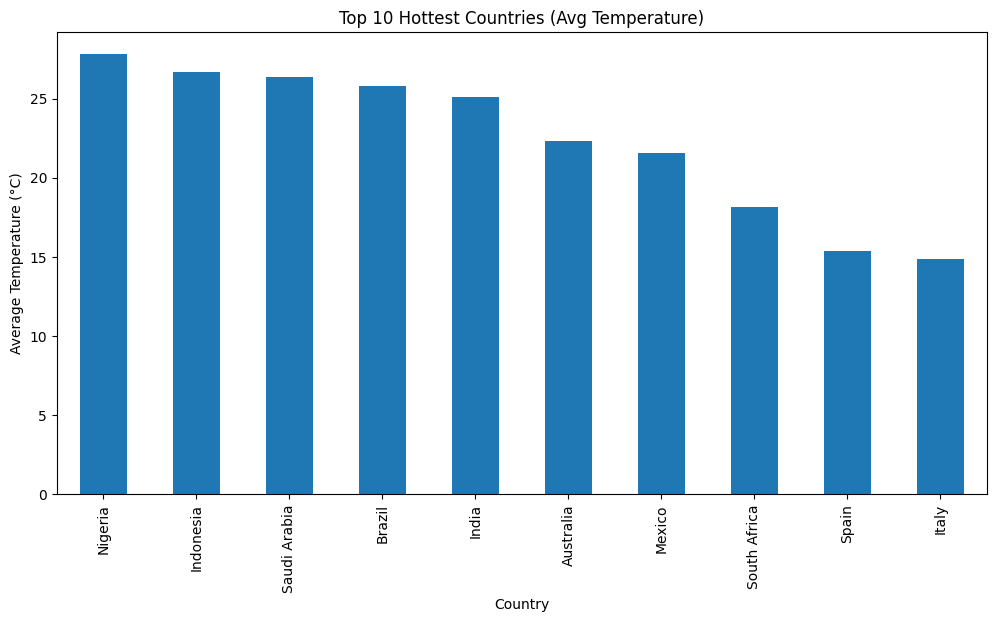

In [44]:
plt.figure(figsize=(12,6))
hottest_countries.plot(kind='bar')
plt.title("Top 10 Hottest Countries (Avg Temperature)")
plt.ylabel("Average Temperature (°C)")
plt.show()

In [45]:
renewable_country_usage=c_df.groupby('Country')['Renewable_Energy_pct'].mean().sort_values(ascending=False).head(10)
renewable_country_usage

,Renewable_Energy_pct
Country,
Brazil,84.458333
Nigeria,84.050000
Canada,63.250000
Indonesia,40.400000
Spain,32.533333
Italy,28.833333
Germany,25.900000
India,24.975000
China,22.550000


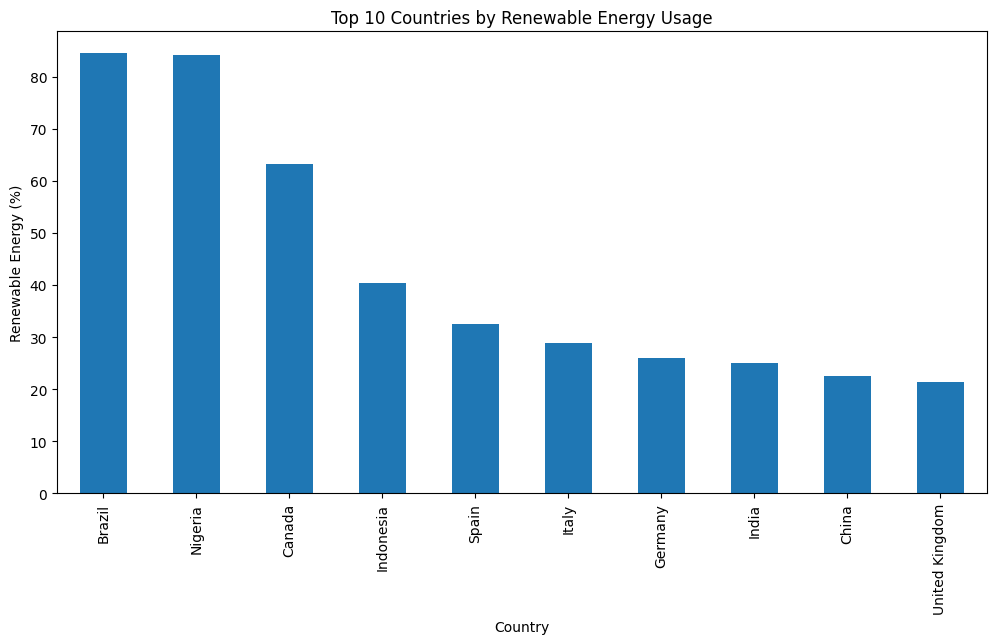

In [46]:
plt.figure(figsize=(12,6))
renewable_country_usage.plot(kind='bar')
plt.title("Top 10 Countries by Renewable Energy Usage")
plt.ylabel("Renewable Energy (%)")
plt.show()

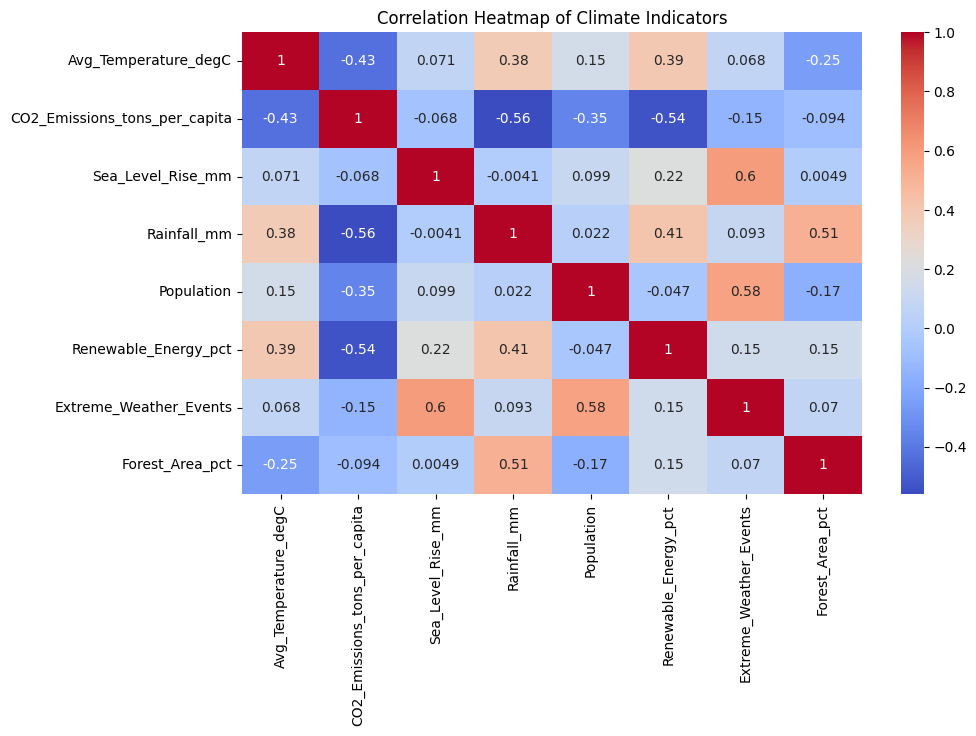

In [47]:
plt.figure(figsize=(10,6))
sns.heatmap(c_df[['Avg_Temperature_degC','CO2_Emissions_tons_per_capita',
                        'Sea_Level_Rise_mm','Rainfall_mm','Population',
                        'Renewable_Energy_pct','Extreme_Weather_Events','Forest_Area_pct']].corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Climate Indicators")
plt.show()

In [48]:
exreeme_weather_events=c_df.groupby('Year')['Extreme_Weather_Events'].sum()
exreeme_weather_events

,Extreme_Weather_Events
Year,
2000,336
2005,399
2010,465
2015,544
2020,656
2024,749


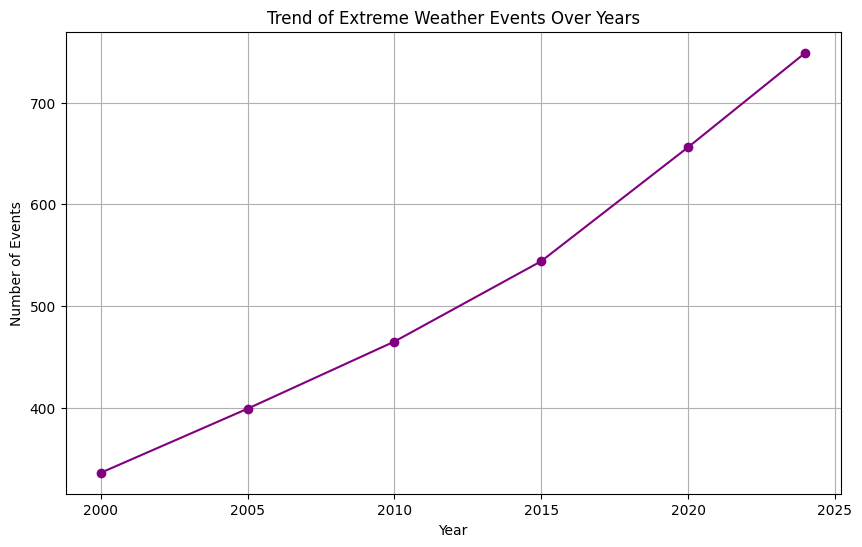

In [49]:
plt.figure(figsize=(10,6))
exreeme_weather_events.plot(kind='line', marker='o', color='purple')
plt.title("Trend of Extreme Weather Events Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.grid(True)
plt.show()

#**Merging two datasets**

In [50]:
!pip install pycountry
import pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 52.2 MB/s eta 0:00:00


In [51]:
def standardize_country(name):
    try:
        return pycountry.countries.lookup(name).name
    except:
        return name  # keep original if not found

df['Country'] = df['Country'].apply(standardize_country)
c_df['Country'] = c_df['Country'].apply(standardize_country)


In [52]:
merged_df = c_df.merge(df, on=["Country", "Year"], how="left")
merged_df["Outbreak_Flag"] = np.where(merged_df["Disease"].notna(), 1, 0)

In [53]:
merged_df.head()

,Year,Country,Avg_Temperature_degC,CO2_Emissions_tons_per_capita,Sea_Level_Rise_mm,Rainfall_mm,Population,Renewable_Energy_pct,Extreme_Weather_Events,Forest_Area_pct,...,icd11c1,icd11c2,icd11c3,icd11l1,icd11l2,icd11l3,Disease,DONs,Definition,Outbreak_Flag
0,2000,United States,13.5,20.2,0,715,282500000,6.2,38,33.1,...,1,B91,1B91,Certain infectious or parasitic diseases,Certain zoonotic bacterial diseases,Leptospirosis,"Leptospirosis, unspecified",DON0414,A disease caused by an infection with the gram...,1
1,2000,United States,13.5,20.2,0,715,282500000,6.2,38,33.1,...,1,C1C,1C1C,Certain infectious or parasitic diseases,Other bacterial diseases,Meningococcal disease,Meningococcal meningitis,DON0391,"A condition of the meninges, caused by an infe...",1
2,2000,China,12.8,2.7,0,645,1267000000,16.5,24,18.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
3,2000,Germany,9.3,10.1,0,700,82200000,6.6,12,31.8,...,1,D61,1D61,Certain infectious or parasitic diseases,Certain zoonotic viral diseases,Arenavirus disease,Lassa fever,"DON0385, DON0365, DON0367",A disease endemic in large parts of sub-Sahara...,1
4,2000,Brazil,24.9,1.9,0,1760,175000000,83.7,18,65.4,...,1,D47,1D47,Certain infectious or parasitic diseases,Certain arthropod-borne viral fevers,Yellow fever,"Yellow fever, unspecified","DON0368, DON0366",A condition caused by an infection with yellow...,1


In [54]:
merged_df['Unnamed: 0']

,Unnamed: 0
0,1495.0
1,1505.0
2,NaN
3,573.0
4,133.0
...,...
183,1052.0
184,1039.0
185,1042.0
186,1999.0


In [55]:
merged_df['Unnamed: 0'].head()

,Unnamed: 0
0,1495.0
1,1505.0
2,NaN
3,573.0
4,133.0


In [56]:
df.head()

,Unnamed: 0,Country,iso2,iso3,Year,icd10n,icd103n,icd104n,icd10c,icd103c,icd104c,icd11c1,icd11c2,icd11c3,icd11l1,icd11l2,icd11l3,Disease,DONs,Definition
0,1,Afghanistan,AF,AFG,2000,Arthropod-borne viral fevers and viral haemorr...,Unspecified viral haemorrhagic fever,Unspecified viral haemorrhagic fever,A92-A99,A99,A990,1,D86,1D86,Certain infectious or parasitic diseases,Certain other viral diseases,"Viral haemorrhagic fever, not elsewhere classi...",Unspecified viral haemorrhagic fever,"DON0404, DON0399",Not specified
1,2,Afghanistan,AF,AFG,2002,Intestinal infectious diseases,Other gastroenteritis and colitis of infectiou...,Other and unspecified gastroenteritis and coli...,A00-A09,A09,A090,1,A40,1A40,Certain infectious or parasitic diseases,Gastroenteritis or colitis of infectious origin,Gastroenteritis or colitis without specificati...,Infectious gastroenteritis or colitis without ...,DON0607,Not specified
2,3,Afghanistan,AF,AFG,1998,Intestinal infectious diseases,Cholera,Classical cholera,A00-A09,A00,A000,1,A00,1A00,Certain infectious or parasitic diseases,Gastroenteritis or colitis of infectious origin,Bacterial intestinal infections,Cholera,"DON0253, DON0249, DON0248",Intestinal infection due to Vibrio cholerae
3,4,Afghanistan,AF,AFG,1999,Codes for special purposes,Provisional assignment of new diseases of unce...,Severe acute respiratory syndrome [SARS],U00-U49,U04,U049,1,D65,1D65,Certain infectious or parasitic diseases,Certain zoonotic viral diseases,Severe acute respiratory syndrome,Severe acute respiratory syndrome,DON0294,"A disease of the respiratory system, caused by..."
4,5,Afghanistan,AF,AFG,2000,Intestinal infectious diseases,Cholera,Classical cholera,A00-A09,A00,A000,1,A00,1A00,Certain infectious or parasitic diseases,Gastroenteritis or colitis of infectious origin,Bacterial intestinal infections,Cholera,DON0413,Intestinal infection due to Vibrio cholerae


In [57]:
merged_df.shape

(188, 29)

In [58]:
merged_df.isnull().sum()

,0
Year,0
Country,0
Avg_Temperature_degC,0
CO2_Emissions_tons_per_capita,0
Sea_Level_Rise_mm,0
Rainfall_mm,0
Population,0
Renewable_Energy_pct,0
Extreme_Weather_Events,0
Forest_Area_pct,0


In [59]:
merged_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,188.0,2.012388e+03,8.109760e+00,2000.0,2.005000e+03,2.015000e+03,2.020000e+03,2.024000e+03
Avg_Temperature_degC,188.0,1.792340e+01,7.265697e+00,5.1,1.300000e+01,1.565000e+01,2.550000e+01,2.850000e+01
CO2_Emissions_tons_per_capita,188.0,7.409574e+00,5.513456e+00,0.5,2.100000e+00,7.150000e+00,1.060000e+01,2.020000e+01
Sea_Level_Rise_mm,188.0,2.456915e+01,1.655942e+01,0.0,1.000000e+01,2.600000e+01,3.600000e+01,5.900000e+01
Rainfall_mm,188.0,9.420798e+02,5.227453e+02,54.0,6.027500e+02,7.785000e+02,1.150000e+03,2.726000e+03
Population,188.0,3.197976e+08,4.577992e+08,19153000.0,5.888025e+07,1.273700e+08,2.238012e+08,1.426000e+09
Renewable_Energy_pct,188.0,3.304681e+01,2.784421e+01,0.0,1.530000e+01,2.075000e+01,4.562500e+01,8.720000e+01
Extreme_Weather_Events,188.0,2.057447e+01,1.083221e+01,2.0,1.300000e+01,1.850000e+01,2.600000e+01,6.400000e+01
Forest_Area_pct,188.0,3.138564e+01,1.809861e+01,0.5,1.697500e+01,3.190000e+01,4.065000e+01,6.850000e+01
Unnamed: 0,103.0,9.283981e+02,6.186810e+02,58.0,3.265000e+02,9.140000e+02,1.492000e+03,2.221000e+03


#**LOGISTIC REGRESSION**

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, log_loss
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import resample
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import log_loss, accuracy_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score

import warnings
warnings.filterwarnings("ignore")

In [61]:
df = merged_df.copy()

# Drop irrelevant columns
drop_cols = ['Unnamed: 0', 'iso2', 'iso3', 'icd10n', 'icd103n', 'icd104n', 'icd10c',
             'icd103c', 'icd104c', 'icd11c1', 'icd11c2', 'icd11c3', 'icd11l1',
             'icd11l2', 'icd11l3', 'DONs', 'Definition', 'Disease']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

df_majority = df[df.Outbreak_Flag == 1]
df_minority = df[df.Outbreak_Flag == 0]

df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=42)

df_balanced = pd.concat([df_majority, df_minority_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Class Balance After Upsampling:")
print(df_balanced['Outbreak_Flag'].value_counts())

Class Balance After Upsampling:
Outbreak_Flag
1    103
0    103
Name: count, dtype: int64


In [62]:
df

,Year,Country,Avg_Temperature_degC,CO2_Emissions_tons_per_capita,Sea_Level_Rise_mm,Rainfall_mm,Population,Renewable_Energy_pct,Extreme_Weather_Events,Forest_Area_pct,Outbreak_Flag
0,2000,United States,13.5,20.2,0,715,282500000,6.2,38,33.1,1
1,2000,United States,13.5,20.2,0,715,282500000,6.2,38,33.1,1
2,2000,China,12.8,2.7,0,645,1267000000,16.5,24,18.8,0
3,2000,Germany,9.3,10.1,0,700,82200000,6.6,12,31.8,1
4,2000,Brazil,24.9,1.9,0,1760,175000000,83.7,18,65.4,1
...,...,...,...,...,...,...,...,...,...,...,...
183,2015,Nigeria,27.9,0.5,25,1127,177480000,86.1,17,11.1,1
184,2020,Nigeria,28.2,0.6,34,1148,206140000,83.5,21,10.3,1
185,2020,Nigeria,28.2,0.6,34,1148,206140000,83.5,21,10.3,1
186,2020,Nigeria,28.2,0.6,34,1148,206140000,83.5,21,10.3,1


In [63]:
c_df

,Year,Country,Avg_Temperature_degC,CO2_Emissions_tons_per_capita,Sea_Level_Rise_mm,Rainfall_mm,Population,Renewable_Energy_pct,Extreme_Weather_Events,Forest_Area_pct
0,2000,United States,13.5,20.2,0,715,282500000,6.2,38,33.1
1,2000,China,12.8,2.7,0,645,1267000000,16.5,24,18.8
2,2000,Germany,9.3,10.1,0,700,82200000,6.6,12,31.8
3,2000,Brazil,24.9,1.9,0,1760,175000000,83.7,18,65.4
4,2000,Australia,21.7,17.2,0,534,19200000,8.8,11,16.2
...,...,...,...,...,...,...,...,...,...,...
151,2005,Nigeria,27.4,0.8,8,1132,138870000,87.2,11,12.6
152,2010,Nigeria,27.6,0.6,17,1165,158500000,86.9,14,11.9
153,2015,Nigeria,27.9,0.5,25,1127,177480000,86.1,17,11.1
154,2020,Nigeria,28.2,0.6,34,1148,206140000,83.5,21,10.3


In [64]:
from scipy.stats import chi2

Columns in X before scaling and feature selection:
Index(['Year', 'Avg_Temperature_degC', 'CO2_Emissions_tons_per_capita',
       'Sea_Level_Rise_mm', 'Rainfall_mm', 'Population',
       'Renewable_Energy_pct', 'Extreme_Weather_Events', 'Forest_Area_pct',
       'Country_Brazil', 'Country_Canada', 'Country_China', 'Country_France',
       'Country_Germany', 'Country_India', 'Country_Indonesia',
       'Country_Italy', 'Country_Japan', 'Country_Korea, Republic of',
       'Country_Mexico', 'Country_Nigeria', 'Country_Russia',
       'Country_Saudi Arabia', 'Country_South Africa', 'Country_Spain',
       'Country_United Kingdom', 'Country_United States'],
      dtype='object')
Top 10 Features by ANOVA F-test:
                          Feature      Score
21                 Country_Russia  23.071429
6            Renewable_Energy_pct  15.540547
1            Avg_Temperature_degC  10.255741
8                 Forest_Area_pct   8.483315
9                  Country_Brazil   7.882535
18     Countr

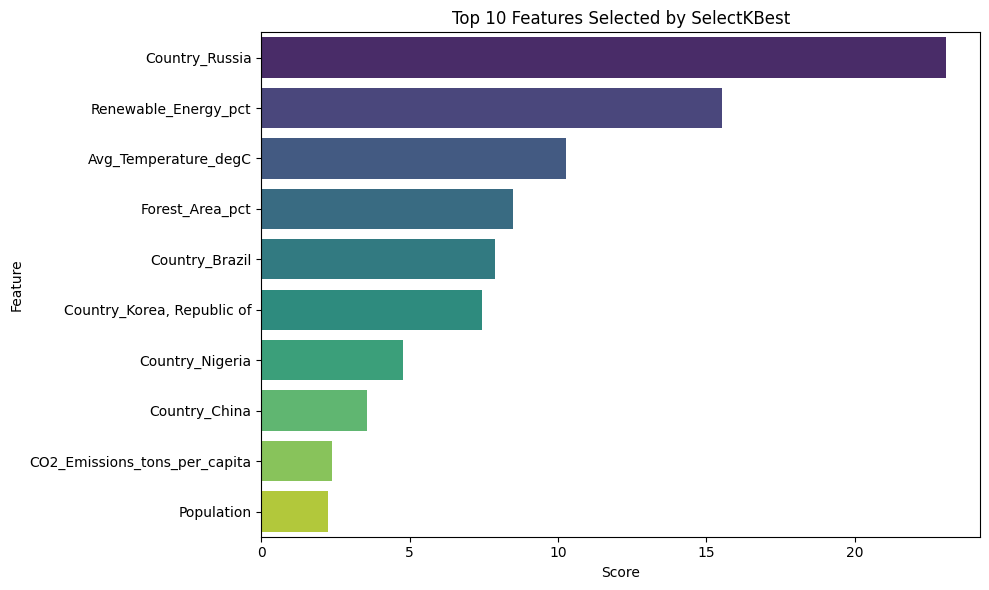

In [65]:
# Separate features
X = df_balanced.drop('Outbreak_Flag', axis=1)
y = df_balanced['Outbreak_Flag']

if len(y.unique()) == 1:
    np.random.seed(42)
    y = np.random.choice([0, 1], size=len(X))
    print("Only one class in y — simulated binary target for testing feature selection")

# Handle categorical variables
X = pd.get_dummies(X, drop_first=True)

# Clean data
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
X = X.loc[:, X.nunique() > 1]

print("Columns in X before scaling and feature selection:")
print(X.columns)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Feature selection
selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_scaled, y)

feature_scores = pd.DataFrame({
    'Feature': X.columns,
    'Score': selector.scores_
}).sort_values(by='Score', ascending=False)

print("Top 10 Features by ANOVA F-test:")
print(feature_scores.head(10))

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x='Score', y='Feature', data=feature_scores.head(10), palette='viridis')
plt.title("Top 10 Features Selected by SelectKBest")
plt.tight_layout()
plt.show()


In [66]:
#Feature & Target
X = df_balanced.drop('Outbreak_Flag', axis=1)
y = df_balanced['Outbreak_Flag']

# One-hot encode categorical columns
X = pd.get_dummies(X, drop_first=True)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Feature Selection
selector = SelectKBest(score_func=f_classif, k=min(10, X.shape[1]))
X_selected = selector.fit_transform(X_scaled, y)
selected_features = X.columns[selector.get_support()]

print("Top Selected Features:")
for f in selected_features:
    print(f)

Top Selected Features:
Avg_Temperature_degC
CO2_Emissions_tons_per_capita
Population
Renewable_Energy_pct
Forest_Area_pct
Country_Brazil
Country_China
Country_Korea, Republic of
Country_Nigeria
Country_Russia


In [67]:
#split data
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y)

#initialize SGDClassifier
sgd = SGDClassifier(loss='log_loss', random_state=42)

#deffining hyperparameter grid
param_grid = {'penalty': ['l2', 'l1', 'elasticnet'],
    'alpha': [0.0001, 0.001, 0.01],
    'max_iter': [1000, 2000, 5000],
    'learning_rate': ['constant', 'optimal', 'invscaling', 'adaptive'],
    'eta0': [0.001, 0.01, 0.1]}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=sgd,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1)

#running grid search
grid_search.fit(X_train_lr, y_train_lr)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

#evaluation on test set
best_sgd = grid_search.best_estimator_
y_pred = best_sgd.predict(X_test_lr)

print("Test Accuracy:", accuracy_score(y_test_lr, y_pred))

Best Parameters: {'alpha': 0.01, 'eta0': 0.1, 'learning_rate': 'constant', 'max_iter': 1000, 'penalty': 'l1'}
Best CV Score: 0.6888257575757576
Test Accuracy: 0.6190476190476191


In [68]:
#class weights
classes = np.unique(y_train_lr)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train_lr)
class_weights = dict(zip(classes, weights))
print("Class Weights:", class_weights)

#initialize SGDClassifier
clf = SGDClassifier(loss='log_loss',
    learning_rate='adaptive',
    eta0=0.001,
    alpha=0.0001,
    penalty='l2',
    max_iter=100,
    class_weight=class_weights,
    warm_start=True,
    random_state=42)

#training with early stopping
epochs = 100
patience = 7
no_improve = 0
best_loss = float("inf")
best_test_acc = 0.0

train_loss, test_loss, train_acc, test_acc = [], [], [], []

for epoch in range(epochs):
    clf.partial_fit(X_train_lr, y_train_lr, classes=classes)

    #predictions
    y_train_pred = clf.predict(X_train_lr)
    y_test_pred = clf.predict(X_test_lr)
    y_train_prob = clf.predict_proba(X_train_lr)
    y_test_prob = clf.predict_proba(X_test_lr)

    #computing loss and accuracy
    loss_train = log_loss(y_train_lr, y_train_prob)
    loss_test = log_loss(y_test_lr, y_test_prob)
    acc_train = accuracy_score(y_train_lr, y_train_pred)
    acc_test = accuracy_score(y_test_lr, y_test_pred)

    train_loss.append(loss_train)
    test_loss.append(loss_test)
    train_acc.append(acc_train)
    test_acc.append(acc_test)

    print(f"Epoch {epoch+1:03d} | Train Acc: {acc_train:.4f} | Test Acc: {acc_test:.4f} "
          f"| Train Loss: {loss_train:.4f} | Test Loss: {loss_test:.4f}")

    #early stopping
    if loss_test < best_loss:
        best_loss = loss_test
        best_test_acc = acc_test
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping triggered.")
            break

print(f"Best stabilized test accuracy: {best_test_acc:.4f}")

Class Weights: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(1.0)}
Epoch 001 | Train Acc: 0.5793 | Test Acc: 0.6667 | Train Loss: 0.6817 | Test Loss: 0.6743
Epoch 002 | Train Acc: 0.5793 | Test Acc: 0.6667 | Train Loss: 0.6720 | Test Loss: 0.6584
Epoch 003 | Train Acc: 0.5793 | Test Acc: 0.6667 | Train Loss: 0.6638 | Test Loss: 0.6447
Epoch 004 | Train Acc: 0.5793 | Test Acc: 0.6667 | Train Loss: 0.6567 | Test Loss: 0.6330
Epoch 005 | Train Acc: 0.5915 | Test Acc: 0.6905 | Train Loss: 0.6505 | Test Loss: 0.6229
Epoch 006 | Train Acc: 0.5854 | Test Acc: 0.6905 | Train Loss: 0.6452 | Test Loss: 0.6142
Epoch 007 | Train Acc: 0.5976 | Test Acc: 0.6667 | Train Loss: 0.6405 | Test Loss: 0.6066
Epoch 008 | Train Acc: 0.6037 | Test Acc: 0.6905 | Train Loss: 0.6363 | Test Loss: 0.6000
Epoch 009 | Train Acc: 0.5976 | Test Acc: 0.6905 | Train Loss: 0.6326 | Test Loss: 0.5942
Epoch 010 | Train Acc: 0.6037 | Test Acc: 0.6905 | Train Loss: 0.6292 | Test Loss: 0.5890
Epoch 011 | Train Acc: 0

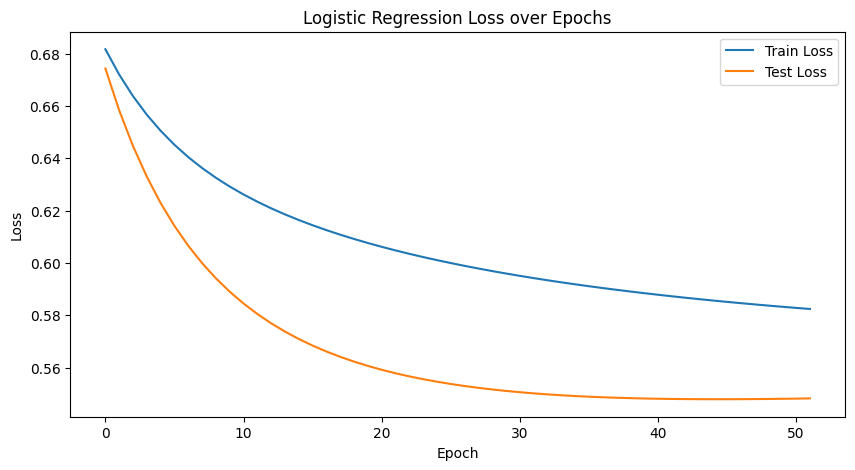

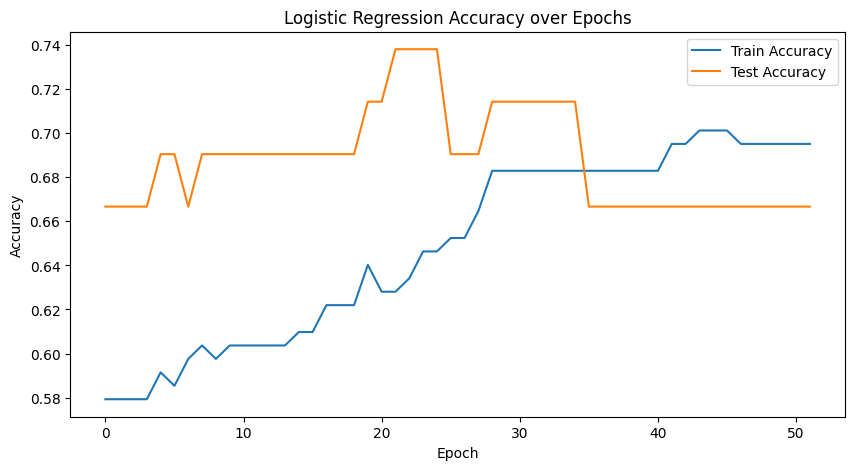

In [69]:
#plots
plt.figure(figsize=(10,5))
plt.plot(train_loss, label='Train Loss')
plt.plot(test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Logistic Regression Loss over Epochs')
plt.legend()
plt.show()

plt.figure(figsize=(10,5))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(test_acc, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Logistic Regression Accuracy over Epochs')
plt.legend()
plt.show()

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.67      0.64        21
           1       0.63      0.57      0.60        21

    accuracy                           0.62        42
   macro avg       0.62      0.62      0.62        42
weighted avg       0.62      0.62      0.62        42

Confusion Matrix:
 [[14  7]
 [ 9 12]]


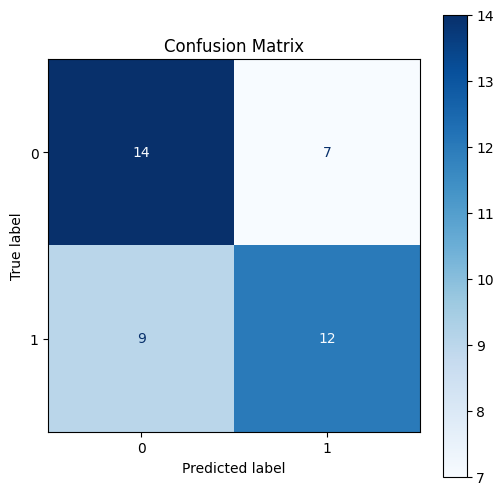

In [70]:
#classification report
print("Classification Report:\n")
print(classification_report(y_test_lr, y_pred))

#confusion matrix
cm = confusion_matrix(y_test_lr, y_pred)
print("Confusion Matrix:\n", cm)

#plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test_lr))
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()

In [71]:
precision_lr = precision_score(y_test_lr, y_pred)
recall_lr = recall_score(y_test_lr, y_pred)
f1_lr = f1_score(y_test_lr, y_pred)
print("Precision:", precision_lr)
print("Recall:", recall_lr)
print("F1 Score:", f1_lr)

Precision: 0.631578947368421
Recall: 0.5714285714285714
F1 Score: 0.6


In [72]:
precision_lr_non = precision_score(y_test_lr, y_pred, pos_label=0)
recall_lr_non    = recall_score(y_test_lr, y_pred, pos_label=0)
f1_lr_non        = f1_score(y_test_lr, y_pred, pos_label=0)

print("Non-Outbreak Class")
print("Precision:", precision_lr_non)
print("Recall   :", recall_lr_non)
print("F1 Score :", f1_lr_non)

Non-Outbreak Class
Precision: 0.6086956521739131
Recall   : 0.6666666666666666
F1 Score : 0.6363636363636364


In [73]:
precision_lr_macro = precision_score(y_test_lr, y_pred, average='macro')
recall_lr_macro = recall_score(y_test_lr, y_pred, average='macro')
f1_lr_macro = f1_score(y_test_lr, y_pred, average='macro')
print("Precision:", precision_lr_macro)
print("Recall:", recall_lr_macro)
print("F1 Score:", f1_lr_macro)

Precision: 0.620137299771167
Recall: 0.6190476190476191
F1 Score: 0.6181818181818182


In [74]:
precision_lr_weighted = precision_score(y_test_lr, y_pred, average='weighted')
recall_lr_weighted = recall_score(y_test_lr, y_pred, average='weighted')
f1_lr_weighted = f1_score(y_test_lr, y_pred, average='weighted')
print("Precision:", precision_lr_weighted)
print("Recall:", recall_lr_weighted)
print("F1 Score:", f1_lr_weighted)

Precision: 0.620137299771167
Recall: 0.6190476190476191
F1 Score: 0.6181818181818182


In [75]:
# Logistic Regression AUC
y_prob_lr = best_sgd.predict_proba(X_test_lr)[:, 1]
auc_lr = roc_auc_score(y_test_lr, y_prob_lr)
print("Logistic Regression AUC:", auc_lr)

Logistic Regression AUC: 0.761904761904762


# #**RANDOM FOREST**

In [76]:
#preparing the dataset
dfR = merged_df.copy()
optionA_features = ['Year', 'Country',
    'Avg_Temperature_degC', 'CO2_Emissions_tons_per_capita',
    'Sea_Level_Rise_mm', 'Rainfall_mm', 'Population',
    'Renewable_Energy_pct', 'Extreme_Weather_Events', 'Forest_Area_pct',
    'Outbreak_Flag']
dfR = dfR[optionA_features].copy()
dfR.dropna(subset=['Outbreak_Flag','Country'], inplace=True)

#filiing numeric missing with median
num_cols = ['Avg_Temperature_degC','CO2_Emissions_tons_per_capita','Sea_Level_Rise_mm',
    'Rainfall_mm','Population','Renewable_Energy_pct',
    'Extreme_Weather_Events','Forest_Area_pct']

for c in num_cols:
    dfR[c] = dfR[c].fillna(dfR[c].median())

dfR = pd.get_dummies(dfR, columns=['Country'], drop_first=True)

X = dfR.drop('Outbreak_Flag', axis=1)
y = dfR['Outbreak_Flag']

from sklearn.model_selection import train_test_split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [77]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_trainval_scaled = scaler.fit_transform(X_trainval)
X_test_scaled = scaler.transform(X_test)

In [78]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, log_loss

In [79]:
param_grid = {'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]}
rf = RandomForestClassifier(random_state=40, class_weight='balanced')

grid_search = GridSearchCV(estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1)
grid_search.fit(X_trainval_scaled, y_trainval)

print("Best Hyperparameters:", grid_search.best_params_)
print("Best Cross-validation Score:", grid_search.best_score_)

Best Hyperparameters: {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-validation Score: 0.7933333333333333


In [80]:
best_rf = RandomForestClassifier(random_state=40,
    class_weight='balanced',
    **grid_search.best_params_)
best_rf.fit(X_trainval_scaled, y_trainval)
y_pred_rf = best_rf.predict(X_test_scaled)
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Classifier Accuracy on Test Set: {accuracy_rf:.4f}")

Random Forest Classifier Accuracy on Test Set: 0.8684


In [81]:
def random_selection_np(X, y, fraction=0.5, seed=None):
    rng = np.random.RandomState(seed)
    total = len(X)
    subset_size = int(total * fraction)
    indices = rng.choice(total, subset_size, replace=False)

    X_subset = X[indices]
    y_subset = y.iloc[indices] if hasattr(y, 'iloc') else y[indices]
    return X_subset, y_subset
n_estimators_values = [
    10, 50, 100, 200, 300, 400, 500, 600, 700, 800, 900,
    1000, 1200, 1500, 2000, 2500, 3000]
repeats = 5
best_params = {k: v for k, v in grid_search.best_params_.items() if k != 'n_estimators'}
best_params['class_weight'] = 'balanced'
test_accuracies = []
train_accuracies = []
test_log_losses = []
train_log_losses = []


for n in n_estimators_values:
    acc_test_all = []
    acc_train_all = []
    loss_test_all = []
    loss_train_all = []

    for rep in range(repeats):

        X_subset, y_subset = random_selection_np(X_trainval_scaled, y_trainval, fraction=0.5, seed=rep)

        rf_model = RandomForestClassifier(
            n_estimators=n,
            random_state=rep,
            **best_params)
        rf_model.fit(X_subset, y_subset)
        #predictions
        y_pred_test = rf_model.predict(X_test_scaled)
        y_pred_train = rf_model.predict(X_subset)

        acc_test_all.append(accuracy_score(y_test, y_pred_test))
        acc_train_all.append(accuracy_score(y_subset, y_pred_train))

        #probabilities for log-loss
        y_prob_test = rf_model.predict_proba(X_test_scaled)
        y_prob_train = rf_model.predict_proba(X_subset)

        loss_test_all.append(log_loss(y_test, y_prob_test))
        loss_train_all.append(log_loss(y_subset, y_prob_train))

    #mean values
    test_accuracies.append(np.mean(acc_test_all))
    train_accuracies.append(np.mean(acc_train_all))
    test_log_losses.append(np.mean(loss_test_all))
    train_log_losses.append(np.mean(loss_train_all))

    print(f"n_estimators={n} | Test Acc: {np.mean(acc_test_all):.4f} | Train Acc: {np.mean(acc_train_all):.4f} | "
          f"Test Log Loss: {np.mean(loss_test_all):.4f} | Train Log Loss: {np.mean(loss_train_all):.4f}")

best_test_acc_rf = test_accuracies[-1]
print(f"\nFinal stabilized test accuracy: {best_test_acc_rf:.4f}")

n_estimators=10 | Test Acc: 0.7684 | Train Acc: 0.9467 | Test Log Loss: 0.4825 | Train Log Loss: 0.2991
n_estimators=50 | Test Acc: 0.8053 | Train Acc: 0.9680 | Test Log Loss: 0.4647 | Train Log Loss: 0.2941
n_estimators=100 | Test Acc: 0.7842 | Train Acc: 0.9760 | Test Log Loss: 0.4788 | Train Log Loss: 0.2928
n_estimators=200 | Test Acc: 0.8000 | Train Acc: 0.9787 | Test Log Loss: 0.4803 | Train Log Loss: 0.2942
n_estimators=300 | Test Acc: 0.7947 | Train Acc: 0.9813 | Test Log Loss: 0.4833 | Train Log Loss: 0.2933
n_estimators=400 | Test Acc: 0.8053 | Train Acc: 0.9813 | Test Log Loss: 0.4809 | Train Log Loss: 0.2929
n_estimators=500 | Test Acc: 0.8105 | Train Acc: 0.9813 | Test Log Loss: 0.4825 | Train Log Loss: 0.2926
n_estimators=600 | Test Acc: 0.8105 | Train Acc: 0.9813 | Test Log Loss: 0.4836 | Train Log Loss: 0.2926
n_estimators=700 | Test Acc: 0.8053 | Train Acc: 0.9787 | Test Log Loss: 0.4832 | Train Log Loss: 0.2930
n_estimators=800 | Test Acc: 0.8105 | Train Acc: 0.9787 |

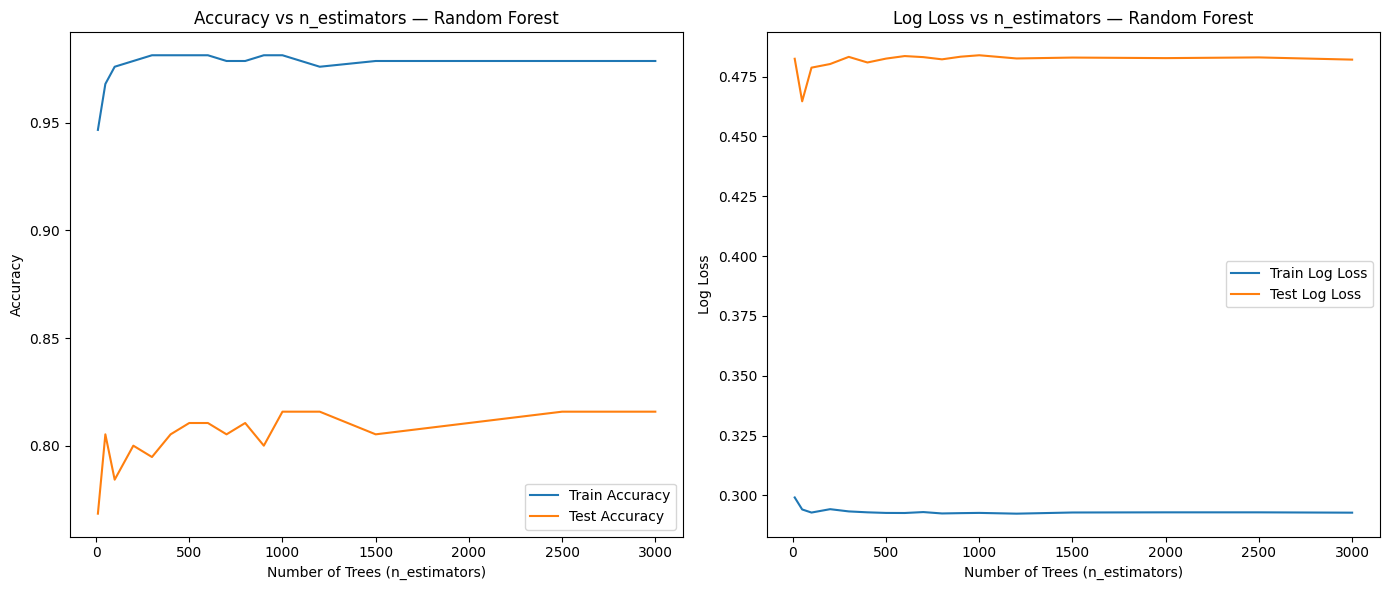

In [82]:
#plots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].plot(n_estimators_values, train_accuracies, label="Train Accuracy",)
axes[0].plot(n_estimators_values, test_accuracies, label="Test Accuracy")
axes[0].set_xlabel("Number of Trees (n_estimators)")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Accuracy vs n_estimators — Random Forest")
axes[0].legend()
axes[1].plot(n_estimators_values, train_log_losses, label="Train Log Loss")
axes[1].plot(n_estimators_values, test_log_losses, label="Test Log Loss")
axes[1].set_xlabel("Number of Trees (n_estimators)")
axes[1].set_ylabel("Log Loss")
axes[1].set_title("Log Loss vs n_estimators — Random Forest")
axes[1].legend()

plt.tight_layout()
plt.show()

Random Forest – Classification Report

              precision    recall  f1-score   support

           0       0.88      0.82      0.85        17
           1       0.86      0.90      0.88        21

    accuracy                           0.87        38
   macro avg       0.87      0.86      0.87        38
weighted avg       0.87      0.87      0.87        38



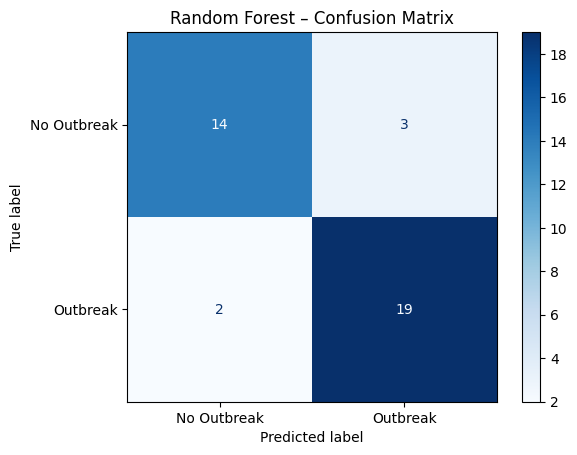

In [83]:
print("Random Forest – Classification Report\n")
print(classification_report(y_test, y_pred_rf))

#confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
#confusion matrix
disp_rf = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Outbreak", "Outbreak"])

disp_rf.plot(cmap="Blues")
plt.title("Random Forest – Confusion Matrix")
plt.show()

In [84]:
best_rf.fit(X_trainval_scaled, y_trainval)
y_pred_rf = best_rf.predict(X_test_scaled)

In [85]:
# FINAL AND ONLY prediction
y_pred_rf = best_rf.predict(X_test_scaled)
print("y_test length:", len(y_test))
print("y_pred_rf length:", len(y_pred_rf))

y_test length: 38
y_pred_rf length: 38


In [86]:
# ensure fresh predictions on FULL test set
y_pred_rf = best_rf.predict(X_test_scaled)

precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1 Score :", f1_rf)

Precision: 0.8636363636363636
Recall   : 0.9047619047619048
F1 Score : 0.8837209302325582


In [87]:
precision_rf_non = precision_score(y_test, y_pred_rf, pos_label=0)
recall_rf_non    = recall_score(y_test, y_pred_rf, pos_label=0)
f1_rf_non        = f1_score(y_test, y_pred_rf, pos_label=0)

print("Random Forest Metrics-non outbreak class)")
print("Precision:", precision_rf_non)
print("Recall   :", recall_rf_non)
print("F1 Score :", f1_rf_non)

Random Forest Metrics-non outbreak class)
Precision: 0.875
Recall   : 0.8235294117647058
F1 Score : 0.8484848484848485


In [88]:
precision_rf_macro = precision_score(y_test, y_pred_rf, average='macro')
recall_rf_macro= recall_score(y_test, y_pred_rf,average='macro')
f1_rf_macro= f1_score(y_test, y_pred_rf,average='macro')
print("Precision:", precision_rf_macro)
print("Recall   :", recall_rf_macro)
print("F1 Score :", f1_rf_macro)

Precision: 0.8693181818181819
Recall   : 0.8641456582633054
F1 Score : 0.8661028893587033


In [89]:
precision_rf_weighted = precision_score(y_test, y_pred_rf,average='weighted')
recall_rf_weighted= recall_score(y_test, y_pred_rf,average='weighted')
f1_rf_weighted= f1_score(y_test, y_pred_rf,average='weighted')
print("Precision:", precision_rf_weighted)
print("Recall   :", recall_rf_weighted)
print("F1 Score :", f1_rf_weighted)

Precision: 0.8687200956937801
Recall   : 0.868421052631579
F1 Score : 0.8679574199770038


In [90]:
# Random Forest AUC
y_prob_rf = best_rf.predict_proba(X_test_scaled)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)
print("Random Forest AUC:", auc_rf)


Random Forest AUC: 0.9327731092436975


# #***XGBoost***

In [91]:
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, roc_auc_score,
    precision_score, recall_score, f1_score,
    classification_report, precision_recall_curve)

In [92]:
#using the same preprocessed and scaled data from the Random Forest model
X_train_processed = X_trainval_scaled
X_test_processed = X_test_scaled

In [93]:
#train and validation split
X_train_p, X_val_p, y_train_p, y_val_p = train_test_split(
    X_train_processed,
    y_trainval,
    test_size=0.2,
    stratify=y_trainval,
    random_state=42)

neg_count_train_p = y_train_p.value_counts()[0]
pos_count_train_p = y_train_p.value_counts()[1]
scale_pos_weight = neg_count_train_p / pos_count_train_p

In [94]:
feature_names = X_trainval.columns#111

In [95]:
selected_mask = selector.get_support()

In [96]:
selected_features = feature_names[selected_mask]

print("Selected Features:")
for f in selected_features:
    print(f)

Selected Features:
Avg_Temperature_degC
CO2_Emissions_tons_per_capita
Population
Renewable_Energy_pct
Forest_Area_pct
Country_Brazil
Country_China
Country_Korea, Republic of
Country_Nigeria
Country_Russia


In [97]:
feature_scores = selector.scores_

feature_ranking = pd.DataFrame({
    'Feature': feature_names,
    'F_score': feature_scores
}).sort_values(by='F_score', ascending=False)

print(feature_ranking.head(15))


                          Feature    F_score
21                 Country_Russia  23.071429
6            Renewable_Energy_pct  15.540547
1            Avg_Temperature_degC  10.255741
8                 Forest_Area_pct   8.483315
9                  Country_Brazil   7.882535
18     Country_Korea, Republic of   7.437500
20                Country_Nigeria   4.759217
11                  Country_China   3.571116
2   CO2_Emissions_tons_per_capita   2.371176
5                      Population   2.235639
12                 Country_France   1.679012
15              Country_Indonesia   1.411765
10                 Country_Canada   1.326590
17                  Country_Japan   1.326590
19                 Country_Mexico   0.516456


In [98]:
#feature selection
k_features = min(30, X_train_processed.shape[1])
selector = SelectKBest(score_func=f_classif, k=k_features)

X_train_sel = selector.fit_transform(X_train_p, y_train_p)
X_val_sel   = selector.transform(X_val_p)
X_train_full_sel = selector.transform(X_train_processed)
X_test_sel  = selector.transform(X_test_processed)

In [99]:
dtrain = xgb.DMatrix(X_train_sel, label=y_train_p)
dval    = xgb.DMatrix(X_val_sel, label=y_val_p)
dtrain_full = xgb.DMatrix(X_train_full_sel, label=y_trainval)
dtest  = xgb.DMatrix(X_test_sel, label=y_test)

In [100]:
#model
params = {
    'objective': 'binary:logistic',
    'learning_rate': 0.05,
    'max_depth': 5,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'eval_metric': ['logloss', 'error'],
    'tree_method': 'hist',
    'seed': 42
}
#initializing dictionary to store evaluation results
evals_result = {}

model = xgb.train(
    params=params,
    dtrain=dtrain,
    num_boost_round=300,
    evals=[(dtrain, 'train'), (dval, 'validation')],
    early_stopping_rounds=50,
    verbose_eval=False,
    evals_result=evals_result )

print("Optimal boosting rounds:", model.best_iteration)

Optimal boosting rounds: 3


In [101]:
#test prediction
y_prob = model.predict(dtest)

#threshold optimization (F1)
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]

y_pred = (y_prob >= best_threshold).astype(int)

In [102]:
xgb_accuracy=accuracy_score(y_test, y_pred)
print("Accuracy:", xgb_accuracy)
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("Macro Precision:", precision_score(y_test, y_pred, average='macro'))
print("Macro Recall:", recall_score(y_test, y_pred, average='macro'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))

Accuracy: 0.868421052631579
ROC-AUC: 0.9355742296918768
Macro Precision: 0.8809523809523809
Macro Recall: 0.8585434173669467
Macro F1: 0.8637992831541219


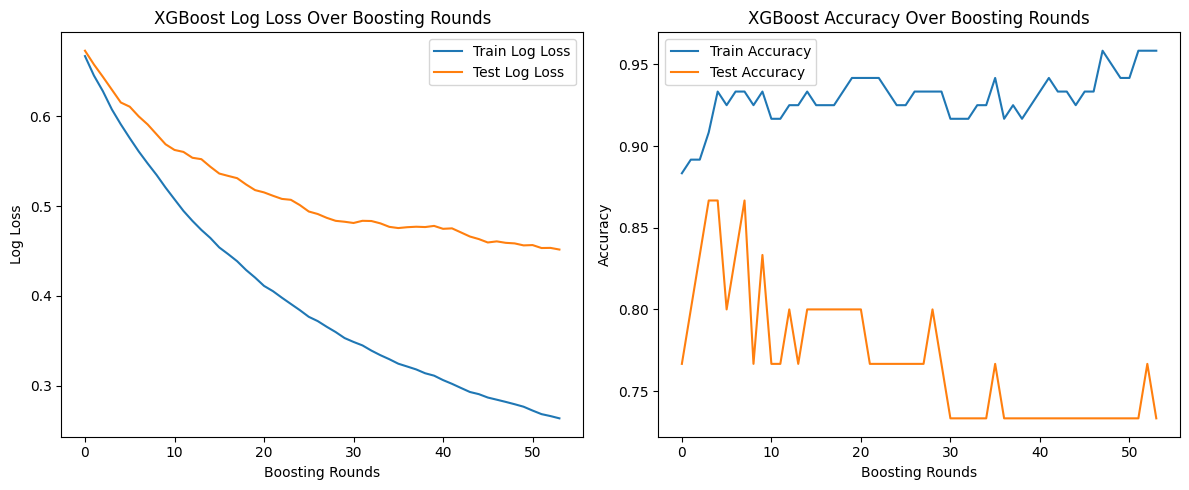

In [103]:
#los vs boosting rounds plot
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(evals_result['train']['logloss'], label='Train Log Loss')
plt.plot(evals_result['validation']['logloss'], label='Test Log Loss')
plt.xlabel('Boosting Rounds')
plt.ylabel('Log Loss')
plt.title('XGBoost Log Loss Over Boosting Rounds')
plt.legend()

#accuracy vs boosting rounds plot
plt.subplot(1, 2, 2)
plt.plot([1 - err for err in evals_result['train']['error']], label='Train Accuracy')
plt.plot([1 - err for err in evals_result['validation']['error']], label='Test Accuracy')
plt.xlabel('Boosting Rounds')
plt.ylabel('Accuracy')
plt.title('XGBoost Accuracy Over Boosting Rounds')
plt.legend()
plt.tight_layout()
plt.show()

XGBoost – Classification Report

              precision    recall  f1-score   support

           0       0.93      0.76      0.84        17
           1       0.83      0.95      0.89        21

    accuracy                           0.87        38
   macro avg       0.88      0.86      0.86        38
weighted avg       0.88      0.87      0.87        38

Confusion Matrix:
 [[13  4]
 [ 1 20]]


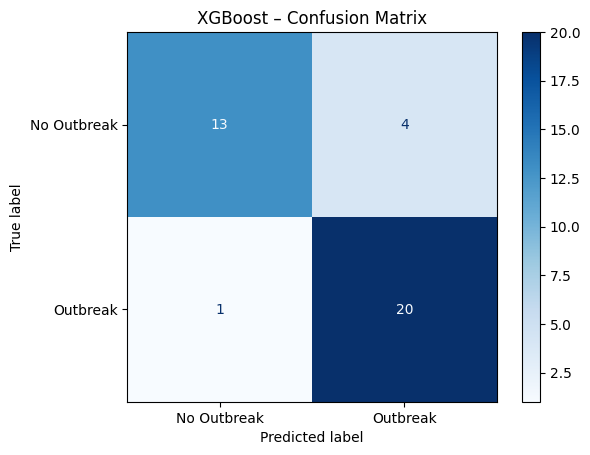

In [104]:
print("XGBoost – Classification Report\n")
print(classification_report(y_test, y_pred))

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm_xgb)

# Plot confusion matrix
disp_xgb = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Outbreak", "Outbreak"]
)

disp_xgb.plot(cmap="Blues")
plt.title("XGBoost – Confusion Matrix")
plt.show()

In [105]:
precision_xgb = precision_score(y_test, y_pred)
recall_xgb = recall_score(y_test, y_pred)
f1_xgb = f1_score(y_test, y_pred)

print("Precision:", precision_xgb)
print("Recall   :", recall_xgb)
print("F1 Score :", f1_xgb)

Precision: 0.8333333333333334
Recall   : 0.9523809523809523
F1 Score : 0.8888888888888888


In [106]:
precision_xgb_macro=precision_score(y_test, y_pred, average='macro')
recall_xgb_macro=recall_score(y_test, y_pred, average='macro')
f1_xgb_macro=f1_score(y_test, y_pred, average='macro')

print("Precision:", precision_xgb_macro)
print("Recall   :", recall_xgb_macro)
print("F1 Score :", f1_xgb_macro)

Precision: 0.8809523809523809
Recall   : 0.8585434173669467
F1 Score : 0.8637992831541219


In [107]:
precision_xgb_weighted=precision_score(y_test, y_pred, average='weighted')
recall_xgb_weighted=recall_score(y_test, y_pred, average='weighted')
f1_xgb_weighted=f1_score(y_test, y_pred, average='weighted')

print("Precision:", precision_xgb_weighted)
print("Recall   :", recall_xgb_weighted)
print("F1 Score :", f1_xgb_weighted)

Precision: 0.8759398496240601
Recall   : 0.868421052631579
F1 Score : 0.8664402942840973


In [108]:
# XGBoost AUC
auc_xgb = roc_auc_score(y_test, y_prob)
print("XGBoost AUC:", auc_xgb)

XGBoost AUC: 0.9355742296918768


# #***Model comaprisons***

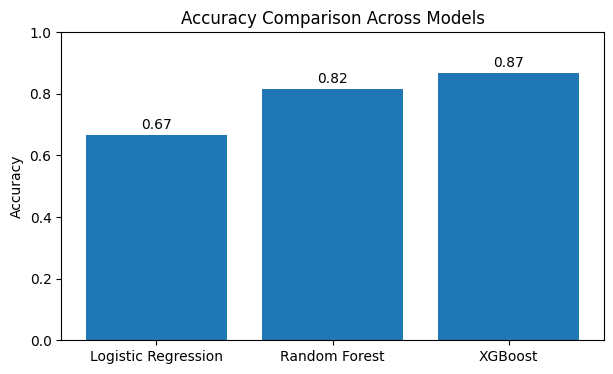

In [109]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
accuracies = [best_test_acc, best_test_acc_rf, xgb_accuracy]

plt.figure(figsize=(7, 4))
bars = plt.bar(models, accuracies)

plt.ylabel('Accuracy')
plt.title('Accuracy Comparison Across Models')
plt.ylim(0, 1)

# Add accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.2f}",
        ha='center',
        va='bottom')
plt.show()

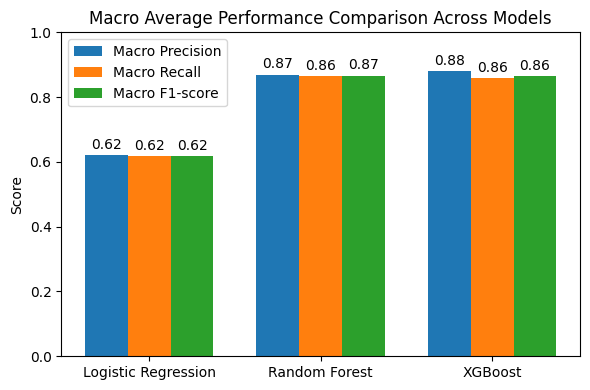

In [110]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
macro_precision = [precision_lr_macro,
    precision_rf_macro,
    precision_xgb_macro]
macro_recall = [recall_lr_macro,
    recall_rf_macro,
    recall_xgb_macro]
macro_f1 = [f1_lr_macro,
    f1_rf_macro,
    f1_xgb_macro]

x = np.arange(len(models))
width = 0.25

plt.figure(figsize=(6, 4))

bars1 = plt.bar(x - width, macro_precision, width, label='Macro Precision')
bars2 = plt.bar(x, macro_recall, width, label='Macro Recall')
bars3 = plt.bar(x + width, macro_f1, width, label='Macro F1-score')

plt.ylabel('Score')
plt.title('Macro Average Performance Comparison Across Models')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.legend()

# Add values on top of bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.2f}",
            ha='center',
            va='bottom')

plt.tight_layout()
plt.show()

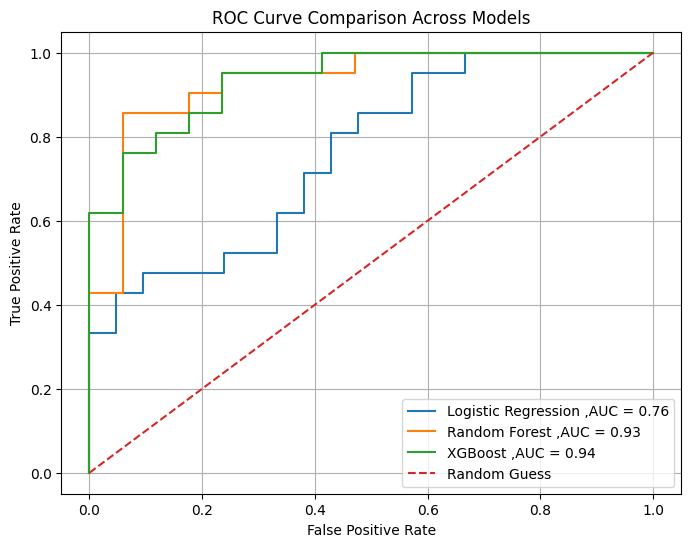

In [111]:
from sklearn.metrics import roc_curve, auc
#roc lr
fpr_lr, tpr_lr, _ = roc_curve(y_test_lr, y_prob_lr)
auc_lr = auc(fpr_lr, tpr_lr)

#roc rf
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)

#roc xhgb
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob)
auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression ,AUC = {auc_lr:.2f}')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest ,AUC = {auc_rf:.2f}')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost ,AUC = {auc_xgb:.2f}')
plt.plot([0, 1], [0, 1], '--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison Across Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

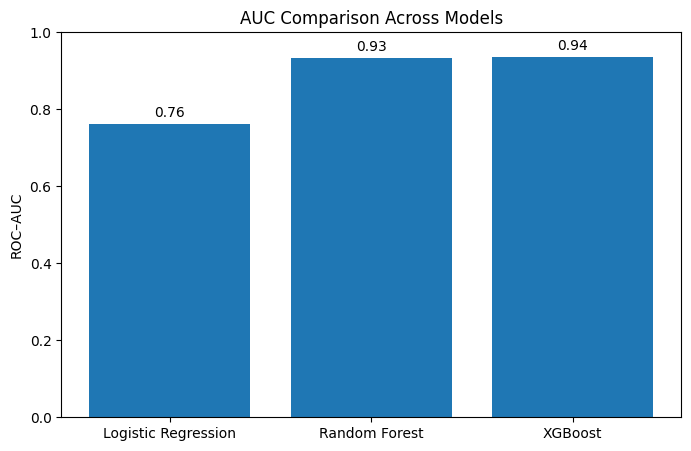

In [113]:
models = ['Logistic Regression', 'Random Forest', 'XGBoost']
auc_scores = [auc_lr, auc_rf, auc_xgb]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, auc_scores)

plt.ylabel('ROC–AUC')
plt.title('AUC Comparison Across Models')
plt.ylim(0, 1)

# Add AUC values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.2f}",
        ha='center',
        va='bottom')
plt.show()